In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_final = pd.read_csv(r'C:\mydata\G8Vitamin\data\final\archive\LOCMM_08062025_DATASET_VITAMINd.csv')

In [4]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30065 entries, 0 to 30064
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SEQN                      30065 non-null  float64
 1   Gender                    30065 non-null  float64
 2   Age                       30065 non-null  float64
 3   Race                      30065 non-null  float64
 4   familysize                30065 non-null  float64
 5   PIR                       27524 non-null  float64
 6   BMXWT                     29603 non-null  float64
 7   BMXHT                     29635 non-null  float64
 8   BMI                       29511 non-null  float64
 9   WaistCircumference        28600 non-null  float64
 10  FastingGlucose            28302 non-null  float64
 11  ALT                       27923 non-null  float64
 12  AST                       27912 non-null  float64
 13  AlkalinePhosphotase       27948 non-null  float64
 14  Choles

In [5]:
threshold = 1e-10

# Select numeric columns
numeric_cols = df_final.select_dtypes(include='number').columns

# Apply threshold replacement only on numeric columns
df_final[numeric_cols] = df_final[numeric_cols].applymap(
    lambda x: 0 if abs(x) < threshold else x
)



C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_23988\2557628910.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_final[numeric_cols] = df_final[numeric_cols].applymap(


In [6]:
# # === Step 1: Create label from VitaminD ===
# def assign_label(x):
#     if pd.isna(x):
#         return None
#     elif x < 50:
#         return 0
#     elif x >= 50 and x < 125:
#         return 1
#     else:
#         return 2

# df_final['label'] = df_final['VitaminD'].apply(assign_label)

# === Bước 2: Trích năm đầu tiên từ chuỗi "2001-2002" ===
# df_final['YearStart'] = df_final['YearID'].astype(str).str.extract(r'(\d{4})').astype(int)
# Tách năm bắt đầu thành cột số nguyên để dễ xử lý
df_final['YearStart'] = df_final['YearID'].str[:4].astype(int)

# # Xử lý cho dữ liệu từ 2001–2012
# df1 = df_final[df_final['YearStart'] < 2013].copy()
# df1.loc[df1['SmokeFam'] == 2, 'SmokeFam'] = 1
# df1 = df1[df1['SmokeFam'] <= 1]

# # Xử lý cho dữ liệu từ 2013 trở đi
# df2 = df_final[df_final['YearStart'] >= 2013].copy()
# df2.loc[(df2['SmokeFam'] >= 1.0) & (df2['SmokeFam'] <= 3.0), 'SmokeFam'] = 1
# df2 = df2[df2['SmokeFam'] <= 1]
# df_final = pd.concat([df1,df2])

def binary_vitamin_d_label(row):
    val = row['VitaminD']
    year = row['YearStart']

    if pd.isna(val) or pd.isna(year):
        return None  # hoặc np.nan

    if year in [2001, 2003]:
        return 1 if val < 20 else 0
    else:
        return 1 if val < 50 else 0

df_final['label'] = df_final.apply(binary_vitamin_d_label, axis=1)

# === Bước 3: Tách dữ liệu theo mốc năm 2013 ===
df_final_train = df_final[df_final['YearStart'] <= 2013]
df_final_test = df_final[df_final['YearStart'] > 2013]

# === Bước 4: Ghi ra file CSV ===
df_final_train.to_csv(r'c:\mydata\G8Vitamin\data\final\06092025\train.csv', index=False)
df_final_test.to_csv(r'c:\mydata\G8Vitamin\data\final\06092025\test.csv', index=False)

# === Log số dòng để xác nhận ===
print(f"✅ Số dòng train: {len(df_final_train)} được lưu vào train.csv")
print(f"✅ Số dòng test : {len(df_final_test)} được lưu vào test.csv")


✅ Số dòng train: 23838 được lưu vào train.csv
✅ Số dòng test : 6227 được lưu vào test.csv


In [7]:
# Read files train
df = pd.read_csv(r'C:\mydata\G8Vitamin\data\final\06092025\train.csv')
df_test = pd.read_csv(r'C:\mydata\G8Vitamin\data\final\06092025\test.csv')

In [8]:
df_test['SmokeFam'].value_counts()

SmokeFam
0.0      2605
1.0       806
2.0       368
3.0        94
999.0       5
777.0       1
Name: count, dtype: int64

In [9]:
df['SmokeFam'] = df.apply(
    lambda row: 0 if row['SmokeFam'] == 2 and int(row['YearStart']) <= 2011 else 1,
    axis=1
)

In [10]:
df_test['Hba1c'].isna().sum()

np.int64(347)

In [11]:
df_test.dropna(subset=['Hba1c'],inplace=True)

In [12]:
df.to_csv(r'c:\mydata\G8Vitamin\data\final\06092025\train.csv', index=False)
df_test.to_csv(r'c:\mydata\G8Vitamin\data\final\06092025\test.csv', index=False)

In [13]:
df['SmokeFam'].value_counts()

SmokeFam
0    16667
1     7171
Name: count, dtype: int64

In [14]:
df_test['SmokeFam'].value_counts()

SmokeFam
0.0      2488
1.0       751
2.0       347
3.0        89
999.0       5
777.0       1
Name: count, dtype: int64

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_23988\2101383360.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=df, palette='viridis')


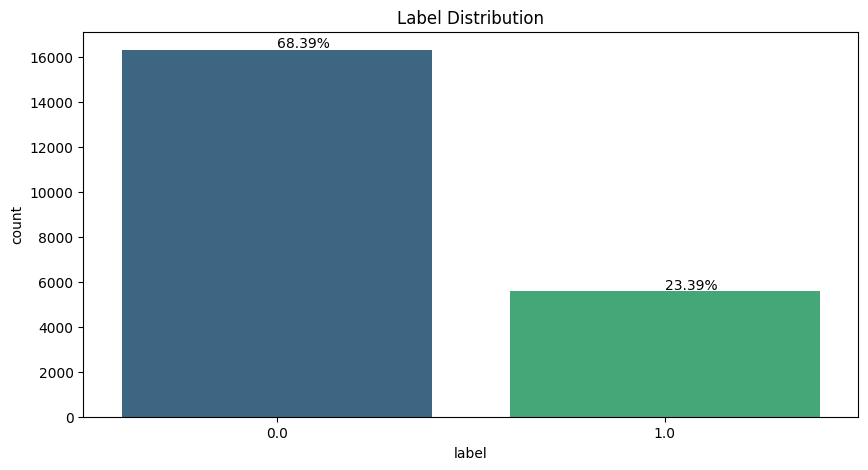

In [15]:
# Draw label distribution
plt.figure(figsize=(10, 5))
ax = sns.countplot(x='label', data=df, palette='viridis')

plt.title('Label Distribution')
for i, rec in enumerate(ax.patches):
    ax.text(
        rec.get_x() + rec.get_width()/2,
        rec.get_height() + 100,
        f'{rec.get_height()/len(df)*100:.2f}%',
    )
plt.show()

### 1. Handle Missing value

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23838 entries, 0 to 23837
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SEQN                      23838 non-null  float64
 1   Gender                    23838 non-null  float64
 2   Age                       23838 non-null  float64
 3   Race                      23838 non-null  float64
 4   familysize                23838 non-null  float64
 5   PIR                       22035 non-null  float64
 6   BMXWT                     23462 non-null  float64
 7   BMXHT                     23490 non-null  float64
 8   BMI                       23376 non-null  float64
 9   WaistCircumference        22722 non-null  float64
 10  FastingGlucose            22439 non-null  float64
 11  ALT                       22143 non-null  float64
 12  AST                       22140 non-null  float64
 13  AlkalinePhosphotase       22169 non-null  float64
 14  Choles

In [17]:
# Drop columns not used fully
cols_drop = [
    "SEQN", "HBsAg",
    "CreatinineUmol"
]

df.drop(columns=cols_drop, inplace=True)

In [18]:
def check_missing_ratio(df_check):
    ratio_completeness = []
    for column in df_check.columns:
        completeness_ratio = df_check[column].notnull().sum() / len(df_check)
        ratio_completeness.append(completeness_ratio)

    # Draw ratio
    plt.figure(figsize=(20, 10)) # type: ignore
    plt.title("Completeness Ratio")
    ax = sns.barplot(y=df_check.columns, x=ratio_completeness, palette='viridis')

    for i, rec in enumerate(ax.patches):
        ax.text(
            rec.get_x() + rec.get_width(),
            rec.get_y() + rec.get_height()/2,
            f'{ratio_completeness[i]:.2%}',
        )

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_23988\1027853617.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=df_check.columns, x=ratio_completeness, palette='viridis')


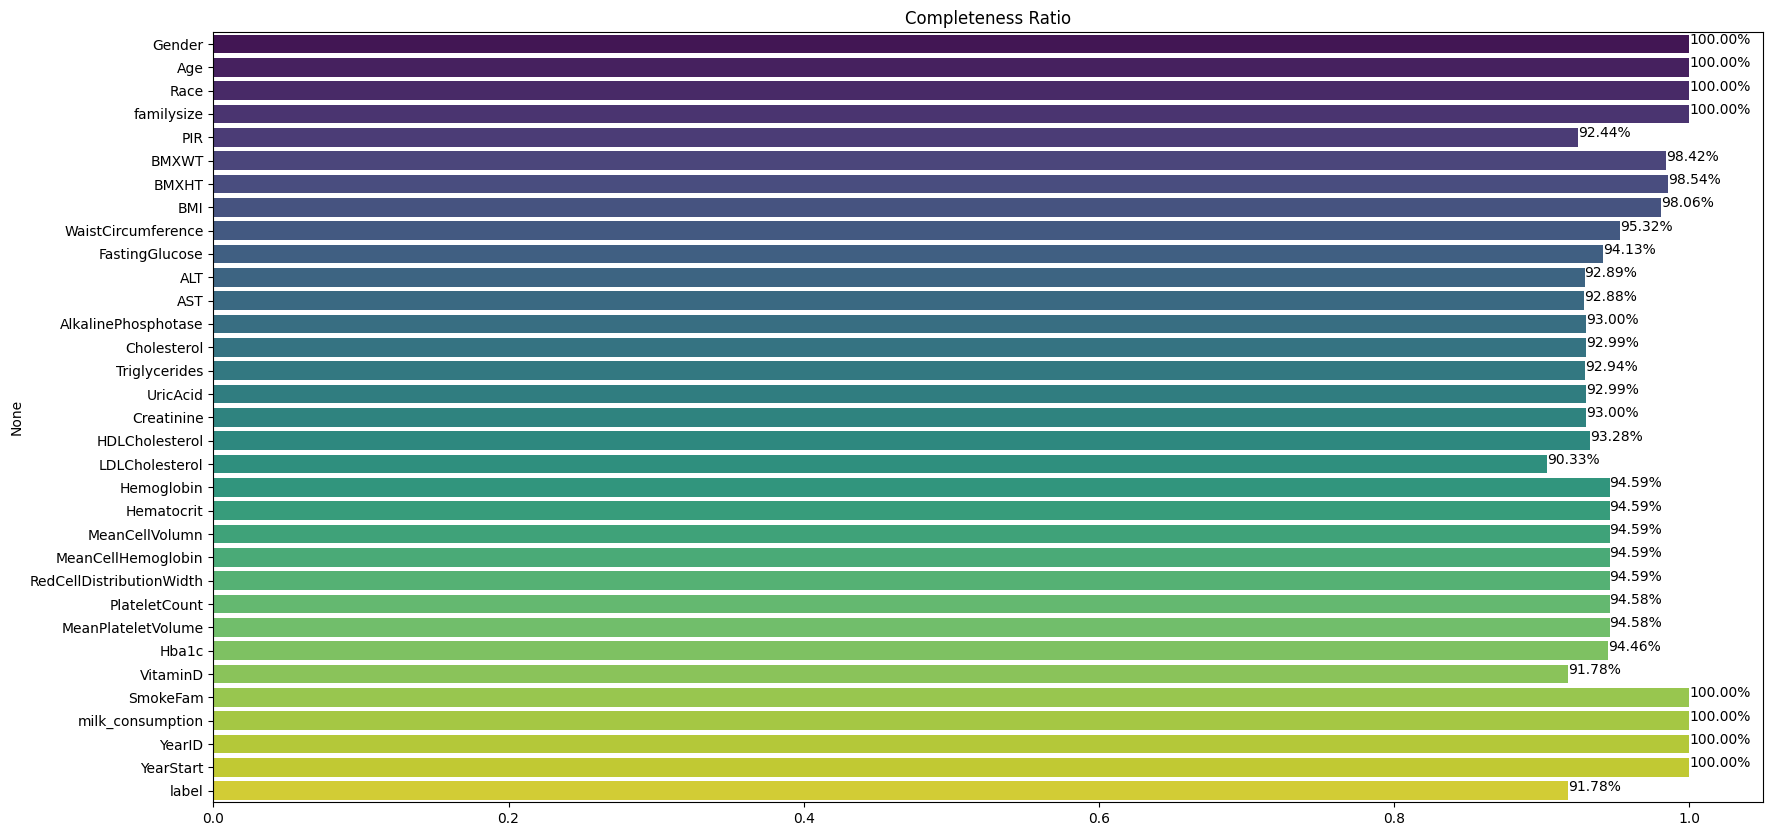

In [19]:
check_missing_ratio(df)

In [20]:
# Drop null vitamin D
df.dropna(subset=['VitaminD'], inplace=True)

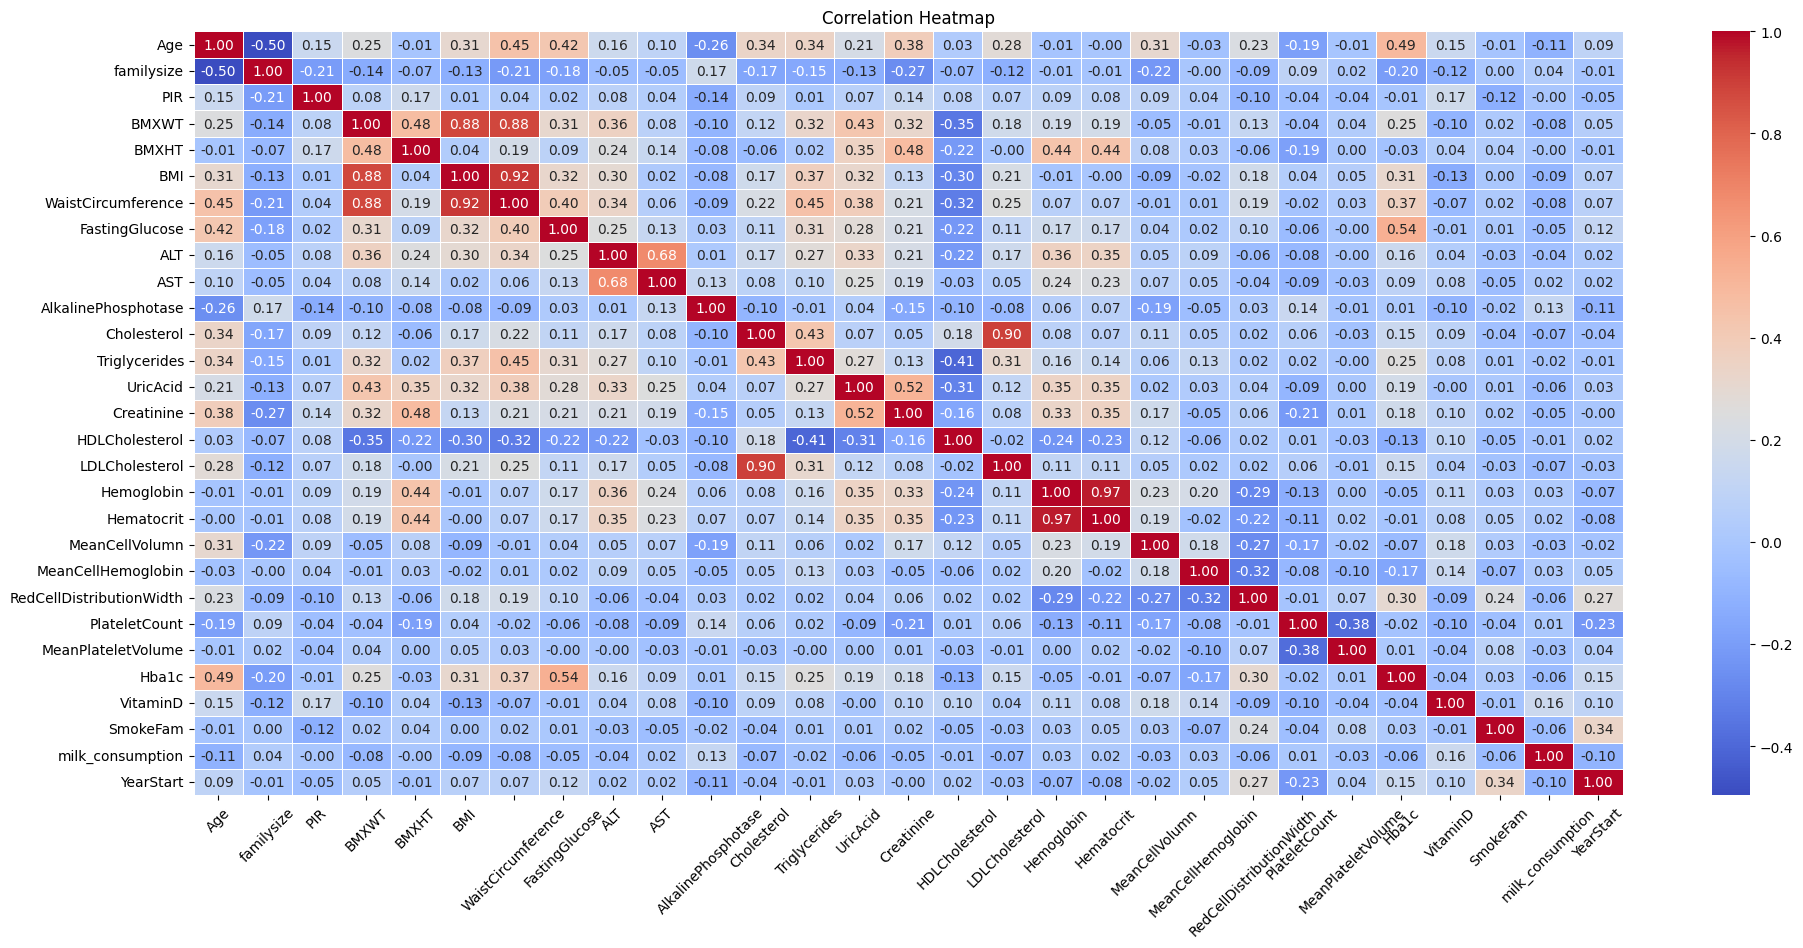

In [22]:
df_corr = df.copy()
df_corr.drop(columns=[
    "Gender", "Race", 
    "label", "YearID",
], inplace=True)

# Check consistency between columns with spearman correlation
correlation_matrix = df_corr.corr(method = "spearman")

plt.figure(figsize=(20, 10))  # Kích thước biểu đồ
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [23]:
# Imputation LDL cholesterol
for index, col in enumerate(['LDLCholesterol', 'HDLCholesterol', 'Triglycerides']):
    for i, row in df.iterrows():
        if pd.isnull(row[col]):
            TotalCholesterol = row['Cholesterol']
            a = ''
            b = ''
            c = 0
            if col == 'LDLCholesterol':
                a = row['HDLCholesterol']
                b = row['Triglycerides']
            elif col == 'HDLCholesterol':
                a = row['LDLCholesterol']
                b = row['Triglycerides']
            else:
                a = row['LDLCholesterol']
                b = row['HDLCholesterol']
            if pd.isnull(TotalCholesterol) or pd.isnull(a) or pd.isnull(b):
                    continue
            
            # Calculate LDL cholesterol using Friedewald formula
            if col == 'Triglycerides':
                c = (TotalCholesterol - a - b)*5
            else:
                c = TotalCholesterol - a - b/5
            df.loc[i, col] = c

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_23988\1027853617.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=df_check.columns, x=ratio_completeness, palette='viridis')


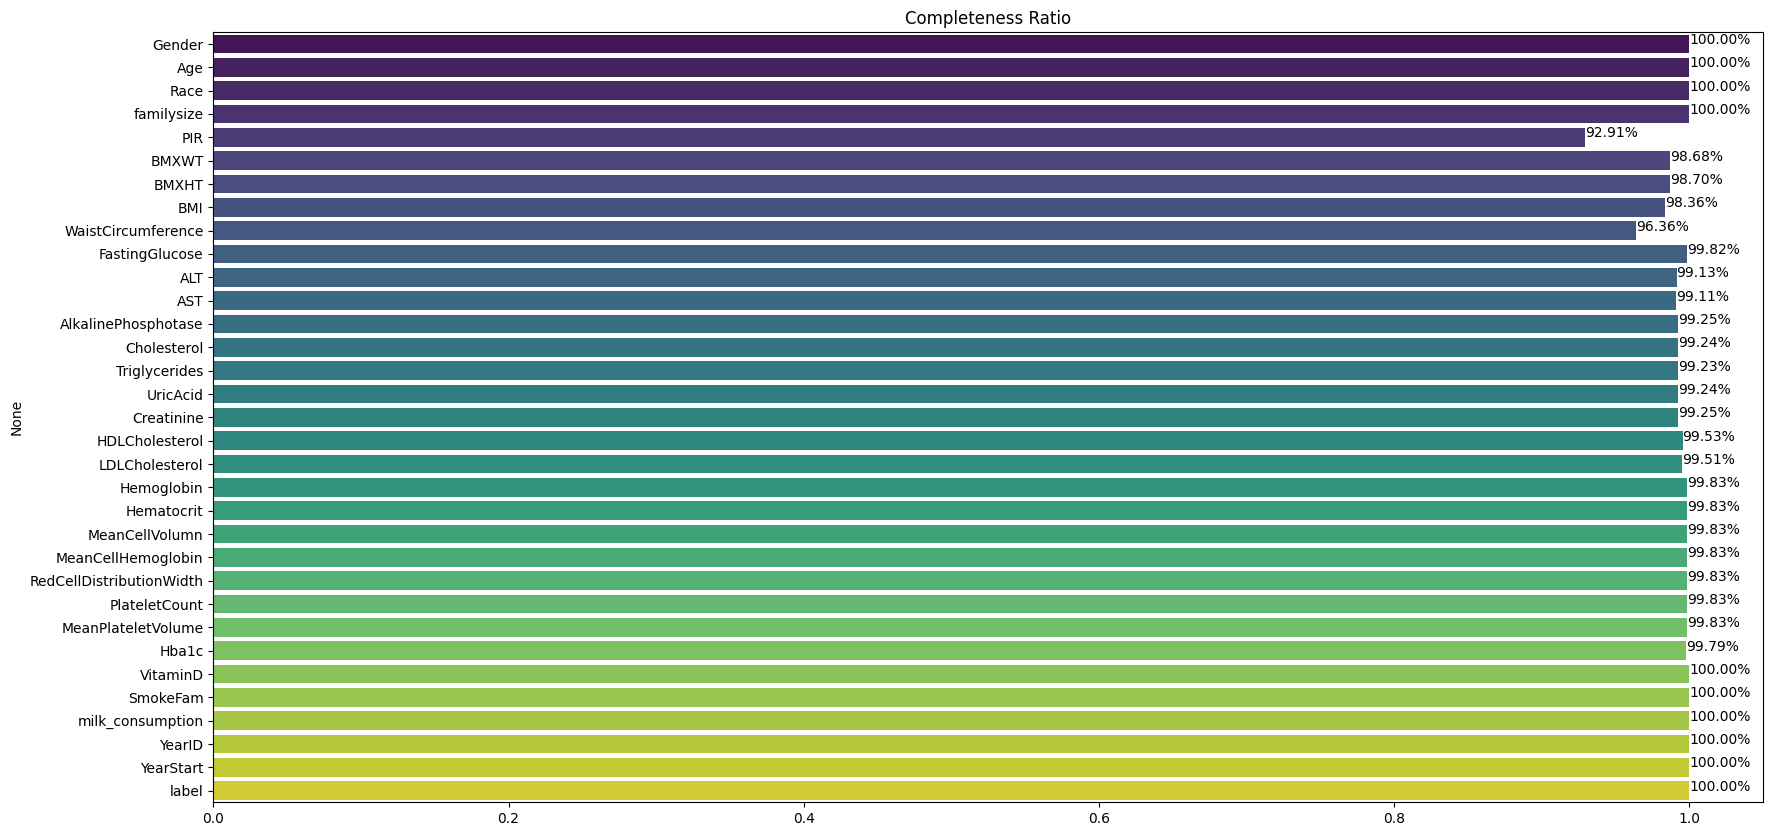

In [24]:
check_missing_ratio(df)

In [26]:
remove_columns = ['familysize','WaistCircumference','Cholesterol', 'BMXWT', 'BMXHT', "YearID"]
df.drop(columns = remove_columns,inplace=True)

### 3. Feature Engineering & Feature Selection

In [27]:
# One hot encoding for race column
df['Race'].value_counts()

Race
3.0    9441
4.0    4833
1.0    4336
5.0    1662
2.0    1606
Name: count, dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21878 entries, 0 to 23837
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    21878 non-null  float64
 1   Age                       21878 non-null  float64
 2   Race                      21878 non-null  float64
 3   PIR                       20326 non-null  float64
 4   BMI                       21519 non-null  float64
 5   FastingGlucose            21839 non-null  float64
 6   ALT                       21687 non-null  float64
 7   AST                       21684 non-null  float64
 8   AlkalinePhosphotase       21713 non-null  float64
 9   Triglycerides             21710 non-null  float64
 10  UricAcid                  21712 non-null  float64
 11  Creatinine                21714 non-null  float64
 12  HDLCholesterol            21775 non-null  float64
 13  LDLCholesterol            21771 non-null  float64
 14  Hemoglobin 

In [29]:
df.columns

Index(['Gender', 'Age', 'Race', 'PIR', 'BMI', 'FastingGlucose', 'ALT', 'AST',
       'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
       'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
       'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
       'PlateletCount', 'MeanPlateletVolume', 'Hba1c', 'VitaminD', 'SmokeFam',
       'milk_consumption', 'YearStart', 'label'],
      dtype='object')

In [30]:
df.dropna(inplace=True)

In [31]:
#diebete assign:
def isDiabete(row):
    if row<6.5:
        return 0
    else:
        return 1

In [32]:
df['Hba1c'] = df['Hba1c'].apply(isDiabete)

c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:48:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


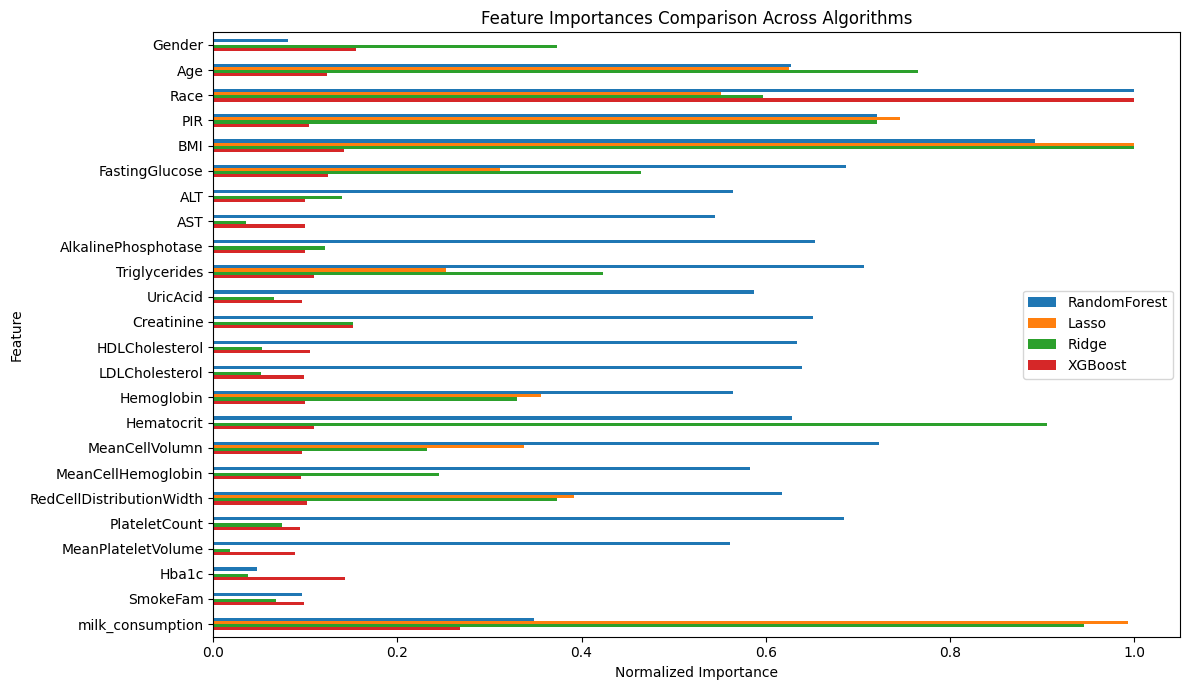

                     Feature  RandomForest     Lasso     Ridge   XGBoost
2                       Race      1.000000  0.551993  0.596882  1.000000
4                        BMI      0.892687  1.000000  1.000000  0.141748
16            MeanCellVolumn      0.722991  0.337213  0.231947  0.096035
3                        PIR      0.720446  0.745494  0.721170  0.103526
9              Triglycerides      0.706517  0.252679  0.423447  0.109056
5             FastingGlucose      0.687202  0.311135  0.464750  0.124189
19             PlateletCount      0.685285  0.000000  0.074212  0.094019
8        AlkalinePhosphotase      0.653325  0.000000  0.120975  0.100025
11                Creatinine      0.651324  0.000000  0.152136  0.151659
13            LDLCholesterol      0.639030  0.000000  0.051402  0.098461
12            HDLCholesterol      0.634075  0.000000  0.053231  0.105284
15                Hematocrit      0.628289  0.000000  0.905025  0.109123
1                        Age      0.627625  0.62546

In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, Ridge, LogisticRegression
import xgboost as xgb
import matplotlib.pyplot as plt

# Load dataset

X = df.drop(columns=['label', 'YearStart', 'VitaminD'])  # Drop non-features
y = df['label']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Standardize for linear models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# 1. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_importance = rf.feature_importances_

# 2. Lasso
lasso = Lasso(alpha=0.01)
lasso.fit(X_scaled, y_train)
lasso_importance = np.abs(lasso.coef_)

# 3. Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y_train)
ridge_importance = np.abs(ridge.coef_)

# 4. XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_importance = xgb_model.feature_importances_

# Aggregate results into a DataFrame
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RandomForest': rf_importance,
    'Lasso': lasso_importance,
    'Ridge': ridge_importance,
    'XGBoost': xgb_importance
})

# Normalize for visualization
for col in ['RandomForest', 'Lasso', 'Ridge', 'XGBoost']:
    importance_df[col] = importance_df[col] / importance_df[col].max()

# Plot top 10 features by Random Forest
top_features = importance_df.sort_values(by='RandomForest', ascending=False).head(30)['Feature']

importance_df_top = importance_df[importance_df['Feature'].isin(top_features)]

importance_df_top.set_index('Feature').plot(kind='barh', figsize=(12, 7))
plt.title("Feature Importances Comparison Across Algorithms")
plt.xlabel("Normalized Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print all results
print(importance_df.sort_values(by='RandomForest', ascending=False).head(30))


In [36]:


# save to csv
df.to_csv(r'c:\mydata\G8Vitamin\data\final\06092025\processed_train.csv', index=False)

In [37]:
df.columns

Index(['Gender', 'Age', 'Race', 'PIR', 'BMI', 'FastingGlucose', 'ALT', 'AST',
       'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
       'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
       'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
       'PlateletCount', 'MeanPlateletVolume', 'Hba1c', 'VitaminD', 'SmokeFam',
       'milk_consumption', 'YearStart', 'label'],
      dtype='object')

## Simple test preparation

In [39]:
df1 = pd.read_csv(r'C:\mydata\G8Vitamin\data\final\06092025\test.csv')

In [40]:
remove_columns = ['Cholesterol', 'BMXWT', 'BMXHT', "YearID","HBsAg"]
df1.drop(columns = remove_columns,inplace=True)

In [41]:
df1.dropna(inplace=True)

In [42]:
df1['Hba1c'].isna().sum()

np.int64(0)

In [43]:
df1['Hba1c'] = df1['Hba1c'].apply(isDiabete)

In [44]:
df1.to_csv(r'c:\mydata\G8Vitamin\data\final\06092025\processed_test.csv', index=False)